In [ ]:
import ee
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import math
import joblib

In [2]:
ee.Authenticate()
ee.Initialize()

In [3]:
CROP_CLASSES = [10,         # Rainfed cropland
                11,         # Herbaceous cover cropland
                12,         # Orchard cropland
                20          # Irrigated cropland
]

TREE_CLASSES = [
    51, 52,                 # Evergreen broadleaved forest
    61, 62,                 # Deciduous broadleaved forest
    71, 72,                 # Evergreen needle-leaved forest
    81, 82,                 # Deciduous needle-leaved forest
    91, 92                  # Mixed forest
]

SHRUB_CLASSES = [
    120, 121, 122,          # Shrubland, Evergreen shrubland, Deciduous shrubland
    152,                    # Sparse shrubland
    130,                    # Grassland
    150,                    # Sparse vegetation
    153                     # Sparse herbaceous cover
]

BARE_CLASSES  = [200,       # Bare areas
                 201,       # Consolidated bare areas
                 202        # Unconsolidated bare areas
]

WATER_CLASSES = [210]       # Water body

BUILT_CLASSES = [190]       # Impervious surface

WETLAND_CLASSES = [181,     # Swamp
                   182,     # Marsh
                   183,     # Flooded flat
                   184,     # Saline 
                   185,     # Mangrove
                   186,     # Salt Marsh
                   187      # Tidal flat
]

SNOW_CLASSES  = [220]

MAJOR_CLASSES = {
    1: CROP_CLASSES,
    2: TREE_CLASSES,
    3: SHRUB_CLASSES,
    4: BARE_CLASSES,
    5: WATER_CLASSES,
    6: BUILT_CLASSES,
    7: WETLAND_CLASSES,
    8: SNOW_CLASSES
}

In [4]:
def remap_to_major(image):
    from_vals = []
    to_vals = []

    for major_id, class_list in MAJOR_CLASSES.items():
        for c in class_list:
            from_vals.append(c)
            to_vals.append(major_id)

    return image.remap(from_vals, to_vals).rename("major_lc")


In [5]:
df = pd.read_csv(
    "./glc_fractions/glc_2022.csv",
    dtype={"s2_id": "string"}  
)

print("Total grids:", len(df))

SAMPLE_SIZE = 20000

df_sample = df.sample(
    n=SAMPLE_SIZE,
    random_state=42 
).reset_index(drop=True)

print("Sample size:", len(df_sample))

Total grids: 2256839
Sample size: 20000


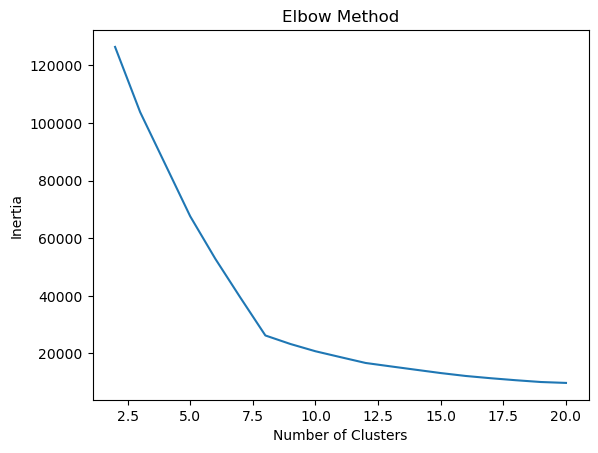

In [6]:
feature_cols = [
    "crop_frac",
    "tree_frac",
    "shrub_frac",
    "bare_frac",
    "water_frac",
    "built_frac",
    "wetland_frac",
    "snow_frac"
]

X = df_sample[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K_range = range(2, 21)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [7]:
K = 8 # optimal no. of clusters using elbow method

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

df_sample["cluster"] = labels
cluster_counts = df_sample["cluster"].value_counts().sort_index()
print(cluster_counts)

cluster
0     5677
1    11171
2      295
3      220
4      216
5     1855
6      345
7      221
Name: count, dtype: int64


C:\Users\navan\AppData\Local\Temp\ipykernel_31120\75501434.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(landcovers, rotation=45, ha='right')
C:\Users\navan\AppData\Local\Temp\ipykernel_31120\75501434.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(landcovers, rotation=45, ha='right')
C:\Users\navan\AppData\Local\Temp\ipykernel_31120\75501434.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(landcovers, rotation=45, ha='right')
C:\Users\navan\AppData\Local\Temp\ipykernel_31120\75501434.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(landcovers, rotation=45, ha='

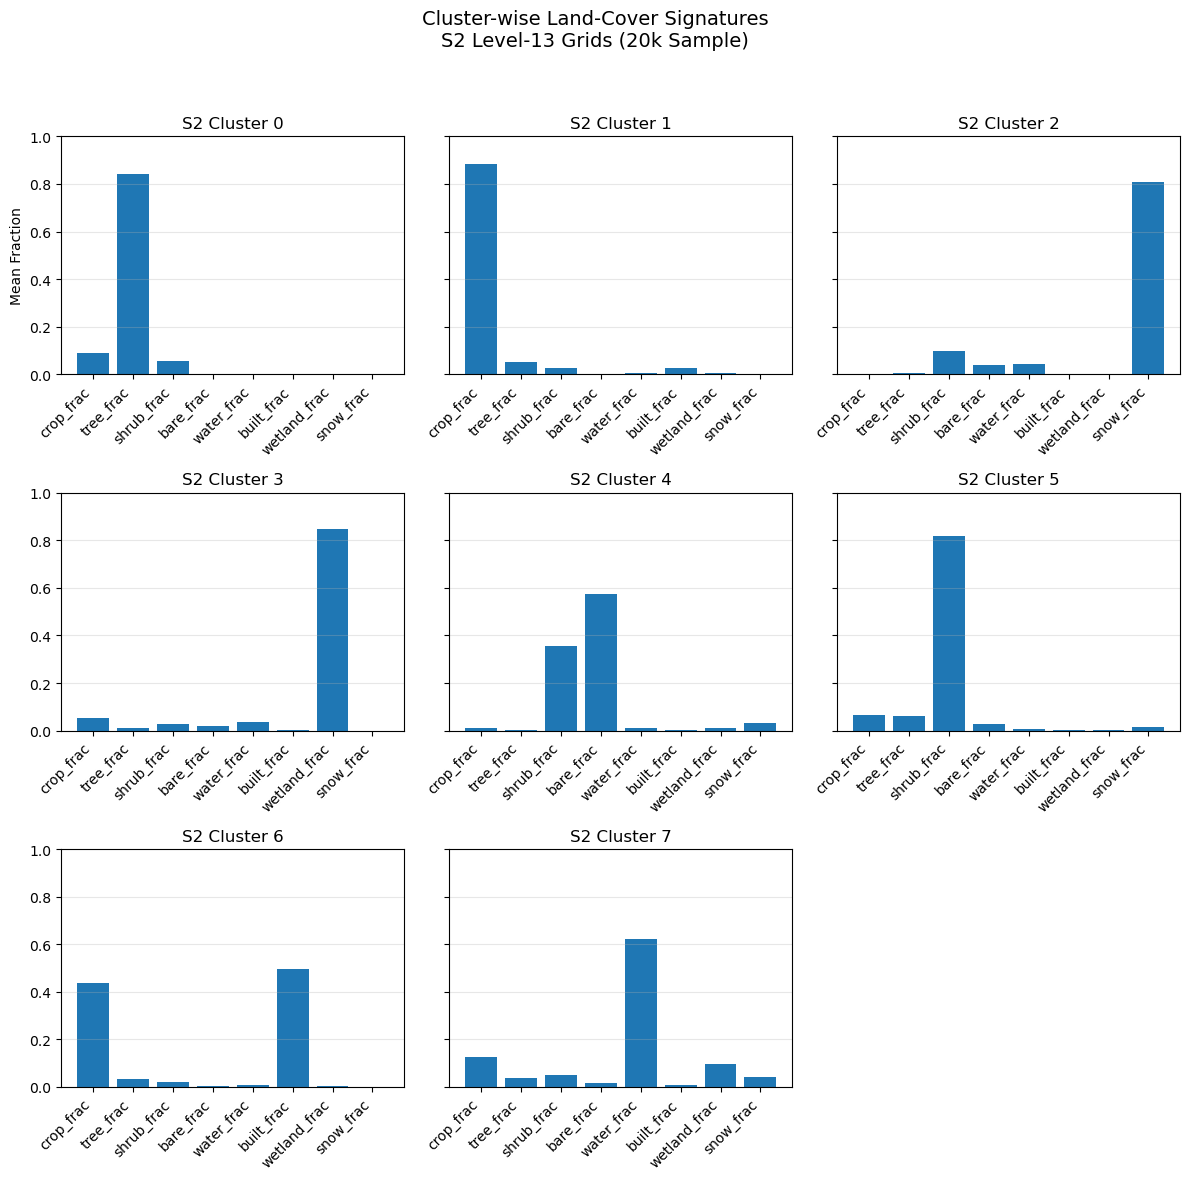

In [ ]:
cluster_means = (
    df_sample.groupby('cluster')[
        [
            'crop_frac',
            'tree_frac',
            'shrub_frac',
            'bare_frac',
            'water_frac',
            'built_frac',
            'wetland_frac',
            'snow_frac'
        ]
    ]
    .mean()
)

landcovers = cluster_means.columns.tolist()
clusters = cluster_means.index.tolist()

n_clusters = len(clusters)
ncols = 3
nrows = math.ceil(n_clusters / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4 * ncols, 4 * nrows),
    sharey=True
)

axes = axes.flatten()

for ax, cl in zip(axes, clusters):

    ax.bar(
        landcovers,
        cluster_means.loc[cl].values
    )

    ax.set_title(f'S2 Cluster {cl}')
    ax.set_ylim(0, 1)
    ax.set_xticklabels(landcovers, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

for ax in axes[len(clusters):]:
    ax.axis('off')

axes[0].set_ylabel('Mean Fraction')

fig.suptitle(
    'Cluster-wise Land-Cover Signatures\nS2 Level-13 Grids (20k Sample)',
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [9]:
joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

C:\Users\navan\AppData\Local\Temp\ipykernel_31120\60621073.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(landcovers, rotation=45, ha='right')
C:\Users\navan\AppData\Local\Temp\ipykernel_31120\60621073.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(landcovers, rotation=45, ha='right')
C:\Users\navan\AppData\Local\Temp\ipykernel_31120\60621073.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(landcovers, rotation=45, ha='right')
C:\Users\navan\AppData\Local\Temp\ipykernel_31120\60621073.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(landcovers, rotation=45, ha='

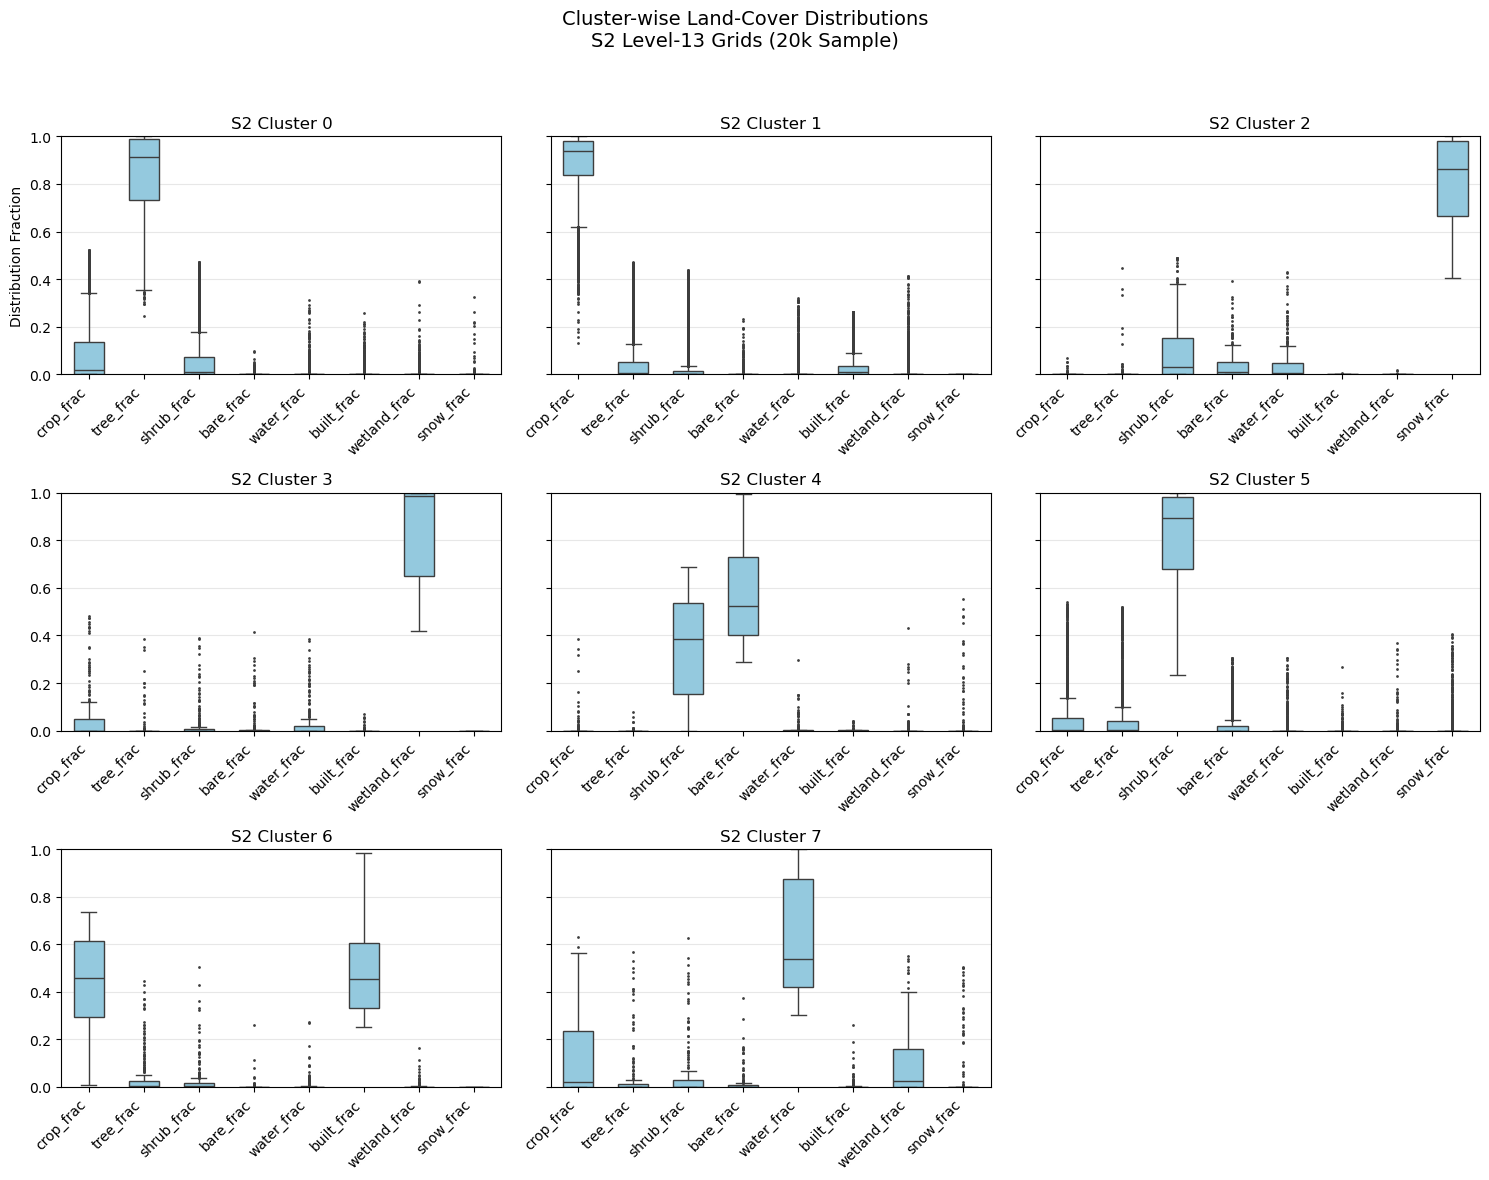

In [10]:
landcovers = [
    'crop_frac',
    'tree_frac',
    'shrub_frac',
    'bare_frac',
    'water_frac',
    'built_frac',
    'wetland_frac',
    'snow_frac',
]
clusters = sorted(df_sample['cluster'].unique().tolist())

n_clusters = len(clusters)
ncols = 3
nrows = math.ceil(n_clusters / ncols)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows), sharey=True
)

axes = axes.flatten()

for ax, cl in zip(axes, clusters):
    cluster_data = df_sample[df_sample['cluster'] == cl][landcovers]

    sns.boxplot(data=cluster_data, ax=ax, color='skyblue', fliersize=1, width=0.55)

    ax.set_title(f'S2 Cluster {cl}')
    ax.set_ylim(0, 1)
    ax.set_xticklabels(landcovers, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

for ax in axes[len(clusters) :]:
    ax.axis('off')

axes[0].set_ylabel('Distribution Fraction')

fig.suptitle(
    'Cluster-wise Land-Cover Distributions\nS2 Level-13 Grids (20k Sample)',
    fontsize=14,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Using cosine similarity 

In [11]:
df = pd.read_csv(
    "./glc_fractions/glc_2022.csv",
    dtype={"s2_id": "string"}  
)
print("Total grids:", len(df))

SAMPLE_SIZE = 20000

df_sample2 = df.sample(
    n=SAMPLE_SIZE,
    random_state=42
).reset_index(drop=True)

Total grids: 2256839


Evaluating cluster counts...
K = 2 calculated.
K = 3 calculated.
K = 4 calculated.
K = 5 calculated.
K = 6 calculated.
K = 7 calculated.
K = 8 calculated.
K = 9 calculated.
K = 10 calculated.
K = 11 calculated.
K = 12 calculated.
K = 13 calculated.
K = 14 calculated.
K = 15 calculated.
K = 16 calculated.
K = 17 calculated.
K = 18 calculated.
K = 19 calculated.
K = 20 calculated.


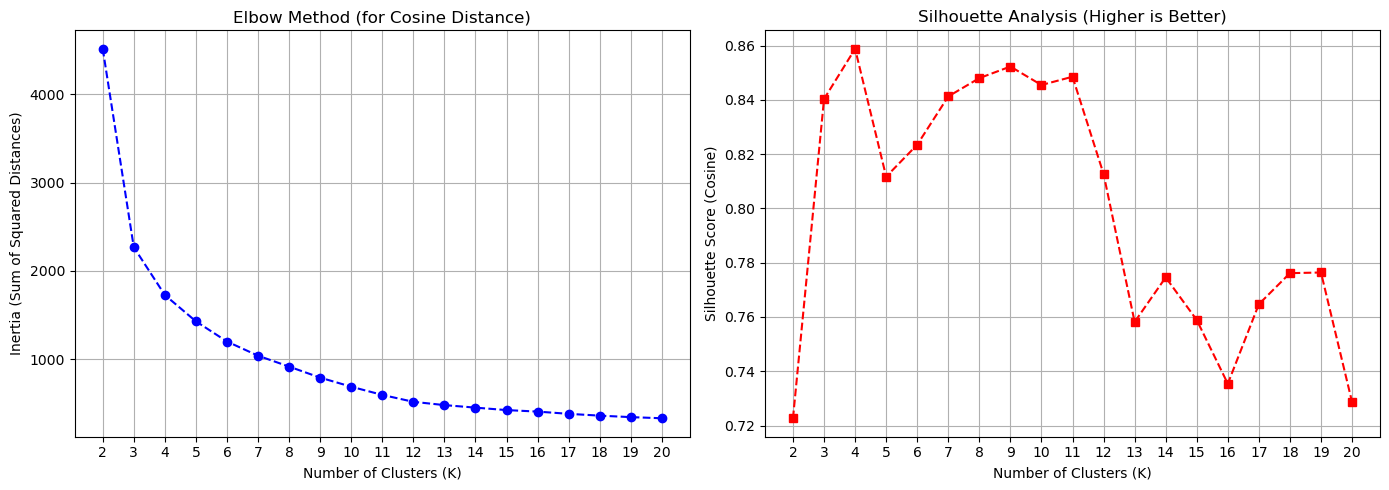

In [ ]:
feature_cols = [
    "crop_frac",
    "tree_frac",
    "shrub_frac",
    "bare_frac",
    "water_frac",
    "built_frac",
    "wetland_frac",
    "snow_frac",
]
X = df_sample2[feature_cols].values

# L2-Normalize features (each row will have a length/norm of 1)
# This forces KMeans to use Cosine Similarity
X_normalized = normalize(X, norm="l2")

inertia = []
silhouette_scores = []
K_range = range(2, 21)  # Testing K from 2 to 20

print("Evaluating cluster counts...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_normalized)

    inertia.append(km.inertia_)

    if len(X_normalized) > 5000:
        idx = np.random.choice(len(X_normalized), 5000, replace=False)
        score = silhouette_score(
            X_normalized[idx], labels[idx], metric="cosine"
        )
    else:
        score = silhouette_score(X_normalized, labels, metric="cosine")
    silhouette_scores.append(score)
    print(f"K = {k} calculated.")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(K_range, inertia, marker="o", color="b", linestyle="--")
ax[0].set_xlabel("Number of Clusters (K)")
ax[0].set_ylabel("Inertia (Sum of Squared Distances)")
ax[0].set_title("Elbow Method (for Cosine Distance)")
ax[0].set_xticks(K_range)
ax[0].grid(True)

ax[1].plot(K_range, silhouette_scores, marker="s", color="r", linestyle="--")
ax[1].set_xlabel("Number of Clusters (K)")
ax[1].set_ylabel("Silhouette Score (Cosine)")
ax[1].set_title("Silhouette Analysis (Higher is Better)")
ax[1].set_xticks(K_range)
ax[1].grid(True)

plt.tight_layout()
plt.savefig("cosine_clustering_evaluation.png")

In [13]:
OPTIMAL_K = 11

kmeans_cosine = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_sample2["cluster"] = kmeans_cosine.fit_predict(X_normalized)

model_filename = "kmeans_cosine_k11_model.joblib"
joblib.dump(kmeans_cosine, model_filename)

print(f"Final Cosine KMeans model successfully trained and saved to '{model_filename}'")
print("\nCluster distribution across your sample data:")
print(df_sample2["cluster"].value_counts().sort_index())

Final Cosine KMeans model successfully trained and saved to 'kmeans_cosine_k11_model.joblib'

Cluster distribution across your sample data:
cluster
0      4620
1     10281
2      1573
3       311
4       240
5       190
6       259
7      1274
8       187
9       483
10      582
Name: count, dtype: int64


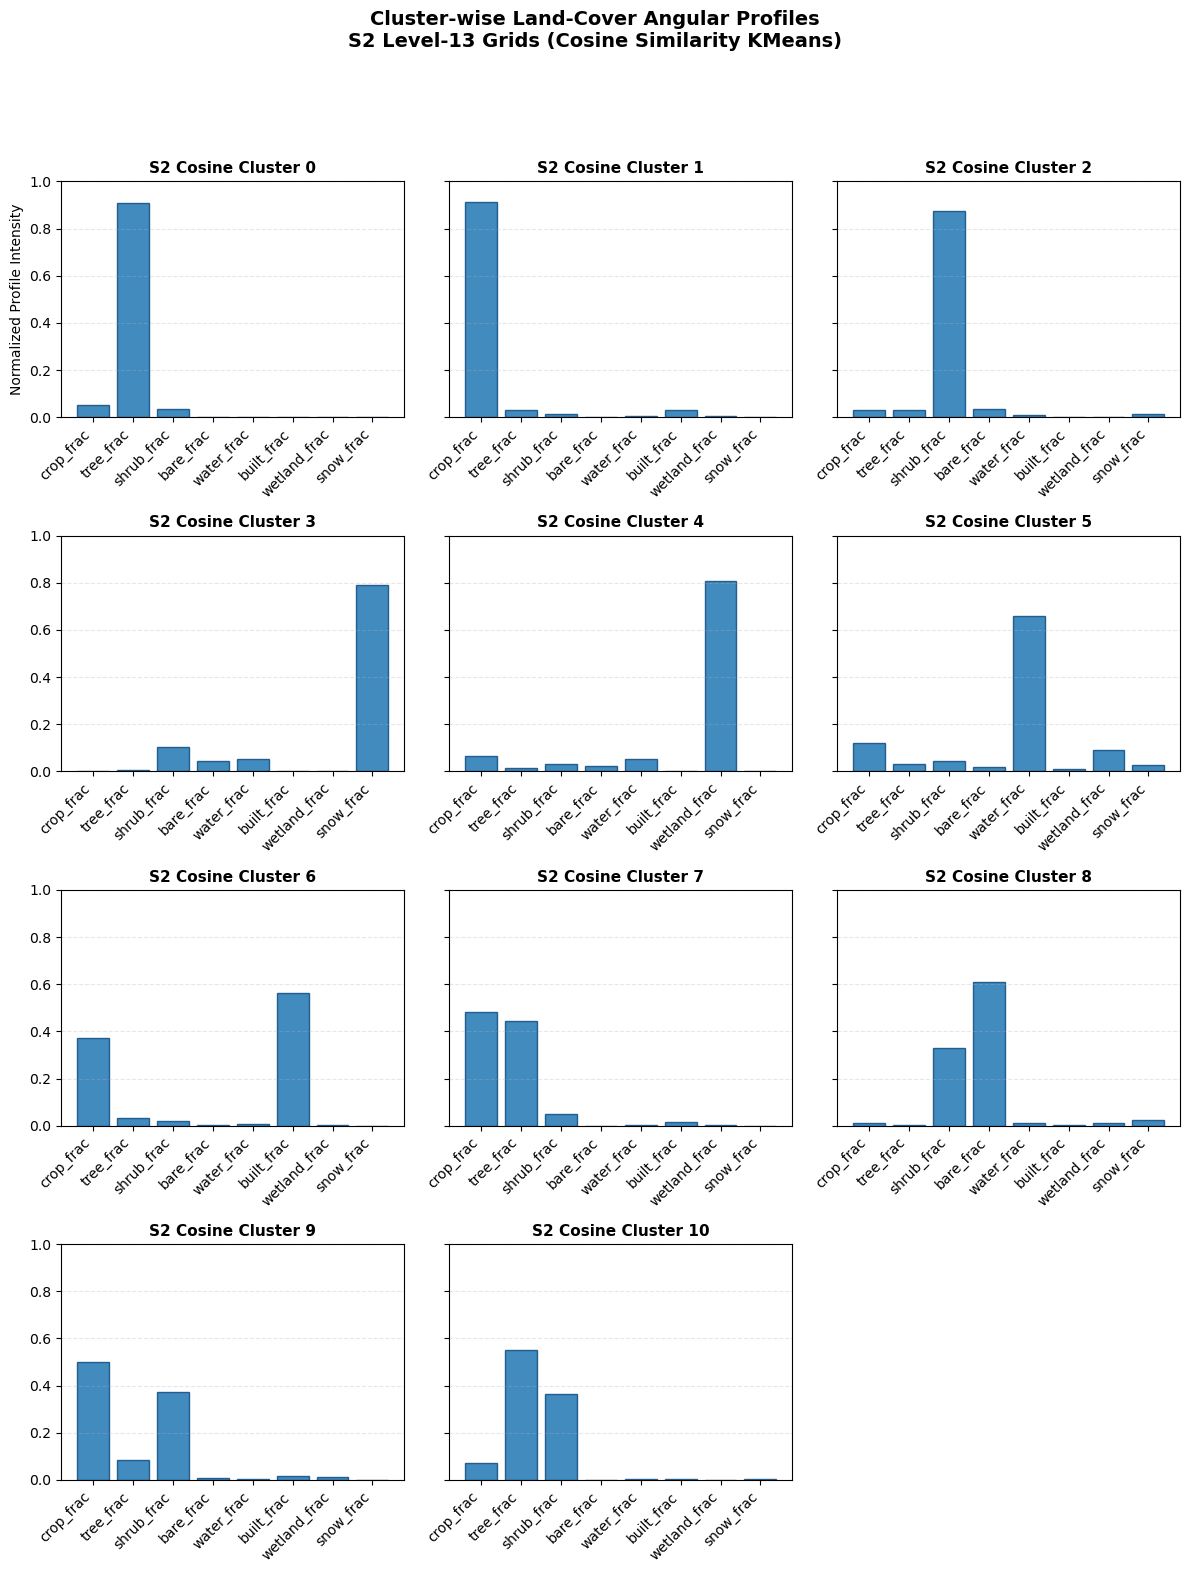

In [14]:
feature_cols = [
    "crop_frac",
    "tree_frac",
    "shrub_frac",
    "bare_frac",
    "water_frac",
    "built_frac",
    "wetland_frac",
    "snow_frac",
]

cluster_profiles_cleaned = df_sample2.groupby("cluster")[feature_cols].mean()

landcovers = cluster_profiles_cleaned.columns.tolist()
clusters = cluster_profiles_cleaned.index.tolist()

n_clusters = len(clusters)
ncols = 3
nrows = math.ceil(n_clusters / ncols)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(4 * ncols, 4 * nrows), sharey=True
)

axes = axes.flatten()

for ax, cl in zip(axes, clusters):

    ax.bar(
        landcovers, 
        cluster_profiles_cleaned.loc[cl].values, 
        color="#1f77b4",       
        edgecolor="#0f4c81",  
        alpha=0.85
    )

    ax.set_title(f"S2 Cosine Cluster {cl}", fontsize=11, fontweight="bold")
    ax.set_ylim(0, 1)

    ax.set_xticks(range(len(landcovers)))
    ax.set_xticklabels(landcovers, rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.3, linestyle="--")

for ax in axes[len(clusters) :]:
    ax.axis("off")

axes[0].set_ylabel("Normalized Profile Intensity")

fig.suptitle(
    "Cluster-wise Land-Cover Angular Profiles\nS2 Level-13 Grids (Cosine Similarity KMeans)",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

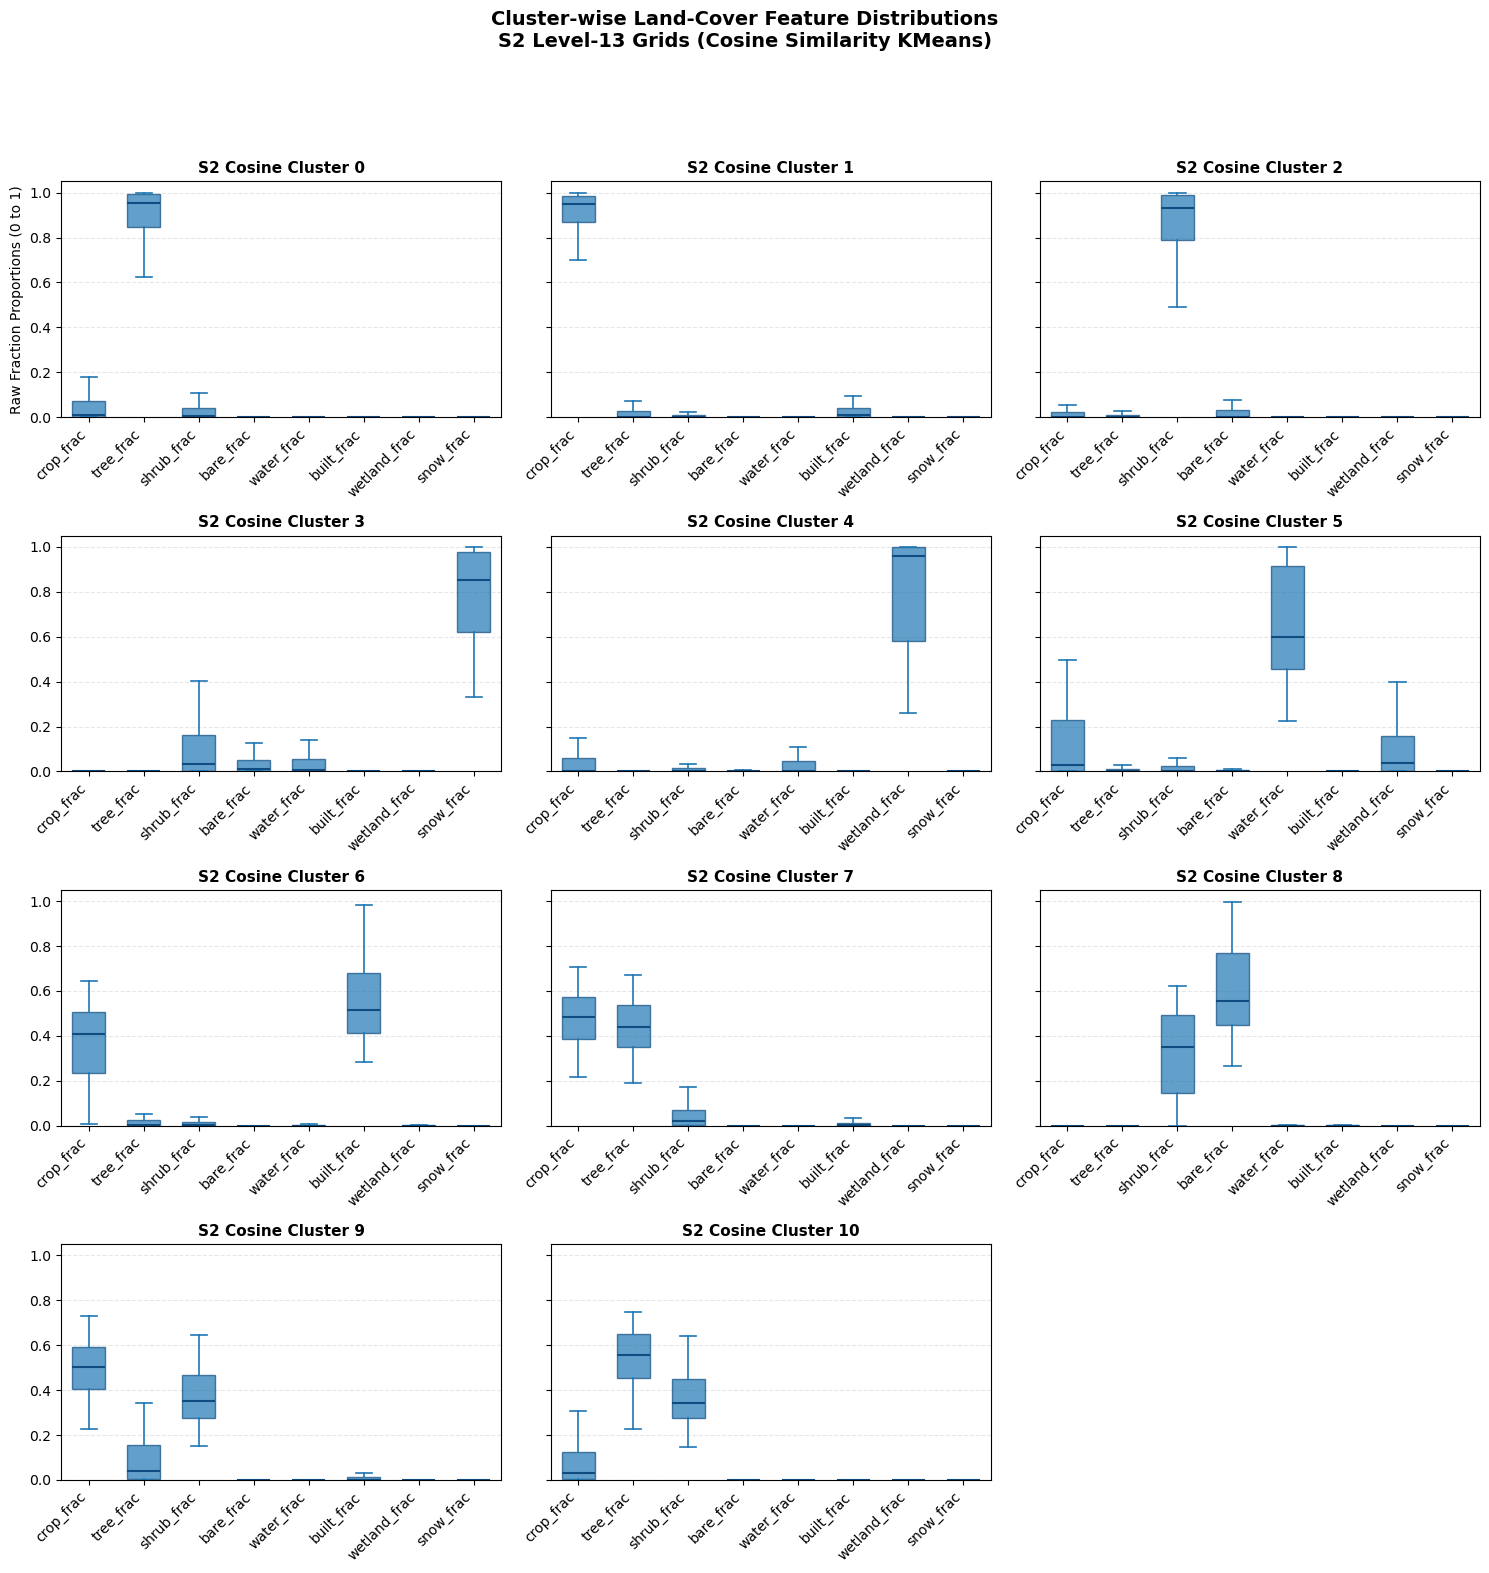

In [15]:
feature_cols = [
    "crop_frac",
    "tree_frac",
    "shrub_frac",
    "bare_frac",
    "water_frac",
    "built_frac",
    "wetland_frac",
    "snow_frac",
]

clusters = sorted(df_sample2["cluster"].unique())

n_clusters = len(clusters)
ncols = 3
nrows = math.ceil(n_clusters / ncols)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows), sharey=True
)

axes = axes.flatten()

for ax, cl in zip(axes, clusters):
    cluster_data = df_sample2[df_sample2["cluster"] == cl][feature_cols]

    boxes = ax.boxplot(
        [cluster_data[col].values for col in feature_cols],
        patch_artist=True,
        widths=0.6,
        showfliers=False,  
        medianprops={"color": "#0f4c81", "linewidth": 1.5}, 
        whiskerprops={"color": "#1f77b4", "linewidth": 1.2},
        capprops={"color": "#1f77b4", "linewidth": 1.2},
    )

    for box in boxes["boxes"]:
        box.set_facecolor("#1f77b4") 
        box.set_edgecolor("#0f4c81") 
        box.set_alpha(0.7)

    ax.set_title(f"S2 Cosine Cluster {cl}", fontsize=11, fontweight="bold")
    
    ax.set_ylim(0, 1.05)  

    ax.set_xticks(range(1, len(feature_cols) + 1))
    ax.set_xticklabels(feature_cols, rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.3, linestyle="--")

for ax in axes[len(clusters) :]:
    ax.axis("off")

axes[0].set_ylabel("Raw Fraction Proportions (0 to 1)")

fig.suptitle(
    "Cluster-wise Land-Cover Feature Distributions\nS2 Level-13 Grids (Cosine Similarity KMeans)",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()